In [1]:
import  sklearn
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import warnings
from sklearn import preprocessing
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
import copy
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time
import lightgbm as lgb
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor

import copy
import numpy as np
from xgboost import DMatrix, train
from sklearn.datasets import make_regression
from flaml import AutoML
np.random.seed(42)
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import pickle
import glob,os
import numpy as np
from scipy.stats import *
import xgboost as xgb
import numpy as np
from scipy.stats import mode
import copy
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# import pickle
# import mgwr
import pandas as pd
import gc
from sklearn.model_selection import train_test_split
import random
from sklearn.feature_selection import mutual_info_regression

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Microsoft YaHei'

# import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.utils import shuffle

<Figure size 1000x600 with 0 Axes>

In [ ]:
"""
refer to the run history.
"""

In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from flaml import AutoML
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_excel(r"E:\DataOfSoftware\xwechat_files\wxid_uxx4wlrvqqzt22_5907\msg\file\2026-01\clfi0904.xlsx") # Ask for the data
data = gpd.GeoDataFrame(  data, crs="EPSG:4326", geometry=gpd.points_from_xy(x=data.lon, y=data.lat))
data

,id,city,year,CLFI,Polycentricity_index,Number_of_centers,Mean_intercenter_distance,Aggregated_central_area,Population_of_the_largest_center,total_center_pop,...,cultivated area2002ln,share of cultivated area2002ln,pop_densityln,Population_concentration,Population_density,lu_area,road_area,lon,lat,geometry
0,1,铜川市,2002,0.473261,0.0,1,0.0,32,17.7000,17.7000,...,7.448757,3.786150,3.068291,20.128046,2.256948,3896.2800,9849.225064,109.033155,35.196027,POINT (109.03316 35.19603)
1,1,铜川市,2003,0.482917,0.0,1,0.0,29,15.8001,15.8001,...,7.448757,3.786150,3.070556,19.154492,2.117089,3896.2800,9849.225064,109.033155,35.196027,POINT (109.03316 35.19603)
2,1,铜川市,2004,0.476707,0.0,1,0.0,30,15.1766,15.1766,...,7.448757,3.786150,3.074715,18.253765,2.133889,3896.2800,9849.225064,109.033155,35.196027,POINT (109.03316 35.19603)
3,1,铜川市,2005,0.460415,0.0,1,0.0,28,15.1102,15.1102,...,7.448757,3.786150,3.075427,18.070122,2.146145,3896.2800,9849.225064,109.033155,35.196027,POINT (109.03316 35.19603)
4,1,铜川市,2006,0.444140,0.0,1,0.0,31,16.3923,16.3923,...,7.448757,3.786150,3.077321,19.506608,2.156791,3896.2800,9849.225064,109.033155,35.196027,POINT (109.03316 35.19603)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4552,217,中卫市,2018,0.365110,0.0,0,0.0,0,0.0000,0.0000,...,7.967330,3.051795,2.191070,0.000000,0.881579,13639.2354,2862.993280,105.501317,37.012845,POINT (105.50132 37.01285)
4553,217,中卫市,2019,0.363661,0.0,1,0.0,124,10.4026,10.4026,...,7.967330,3.051795,2.191070,8.620930,0.884704,13639.2354,2862.993280,105.501317,37.012845,POINT (105.50132 37.01285)
4554,217,中卫市,2020,0.365436,0.0,1,0.0,128,10.4503,10.4503,...,7.967330,3.051795,2.059878,8.633215,0.887495,13639.2354,2862.993280,105.501317,37.012845,POINT (105.50132 37.01285)
4555,217,中卫市,2021,0.366713,0.0,1,0.0,143,13.7832,13.7832,...,7.967330,3.051795,2.191070,11.403458,0.886183,13639.2354,2862.993280,105.501317,37.012845,POINT (105.50132 37.01285)


In [4]:
data['CLFI']=data['CLFI']*100

In [ ]:
y = data.CLFI

X_coords = data[ ['Polycentricity_index', 'Number_of_centers', 'Mean_intercenter_distance', 'Aggregated_central_area', 'Population_of_the_largest_center', 'Population_concentration',
                  'is','employment_share', 'cultivated area2002', 'built_up_area','lu_area','road_area','Population_density', 'Urbanization_rate', 'Number_of_high_speed_rail_stations', 
                  'Built_up_land_area_proportion', 'Road_area_proportion', 
                 'Slope', 'Relief_degree_of_land_surface', 'Water_area_proportion', 'lon', 'lat']]
X_coords

,Polycentricity_index,Number_of_centers,Mean_intercenter_distance,Aggregated_central_area,Population_of_the_largest_center,Population_concentration,is,employment_share,cultivated area2002,built_up_area,...,Population_density,Urbanization_rate,Number_of_high_speed_rail_stations,Built_up_land_area_proportion,Road_area_proportion,Slope,Relief_degree_of_land_surface,Water_area_proportion,lon,lat
0,0.0,1,0.0,32,17.7000,20.128046,0.899267,98.994516,1717.726464,20.0,...,2.256948,46.62,0,0.010593,18.158826,10.9929,1.133245,0.078398,109.033155,35.196027
1,0.0,1,0.0,29,15.8001,19.154492,0.907230,99.030068,1717.726464,35.0,...,2.117089,46.96,0,0.010889,38.581793,10.9929,1.133245,0.077820,109.033155,35.196027
2,0.0,1,0.0,30,15.1766,18.253765,0.911685,98.962656,1717.726464,36.0,...,2.133889,47.30,0,0.011268,48.989288,10.9929,1.133245,0.077243,109.033155,35.196027
3,0.0,1,0.0,28,15.1102,18.070122,0.913775,98.849372,1717.726464,36.0,...,2.146145,46.15,0,0.011507,46.271920,10.9929,1.133245,0.077127,109.033155,35.196027
4,0.0,1,0.0,31,16.3923,19.506608,0.920934,98.924731,1717.726464,36.0,...,2.156791,47.23,0,0.011977,43.887365,10.9929,1.133245,0.076873,109.033155,35.196027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4552,0.0,0,0.0,0,0.0000,0.000000,0.856771,94.548839,2885.144576,32.0,...,0.881579,44.41,0,0.006617,20.778571,5.8751,1.680889,0.478538,105.501317,37.012845
4553,0.0,1,0.0,124,10.4026,8.620930,0.862482,97.283140,2885.144576,30.0,...,0.884704,44.82,2,0.006709,25.713889,5.8751,1.680889,0.484061,105.501317,37.012845
4554,0.0,1,0.0,128,10.4503,8.633215,0.845658,97.431208,2885.144576,30.0,...,0.887495,49.70,2,0.006785,21.271477,5.8751,1.680889,0.470718,105.501317,37.012845
4555,0.0,1,0.0,143,13.7832,11.403458,0.851500,97.484241,2885.144576,31.0,...,0.886183,50.51,2,0.006821,24.025630,5.8751,1.680889,0.467617,105.501317,37.012845


In [48]:
y.max()

np.float64(59.29175019264221)

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd


feature_name_map = {
    'Polycentricity_index'         : 'Polycentricity',
    'Number_of_centers'             : 'Num_Centers',
    'Mean_intercenter_distance':    'Mean_Dist',
    'Aggregated_central_area':       'Agg_Central_Area',
    'Population_of_the_largest_center': 'Pop_Largest_Center',
    'Population_concentration': 'Pop_Concentration',

    'is': 'Intur_Stru',
    'employment_share': 'Enploy_Sha',
    'cultivated area2002': 'Culti_Area',
    'built_up_area': 'Built_Area',
    'lu_area': 'Total_Area',
    'road_area': 'Road_Area',
    'Population_density': 'Pop_Density',
    'Urbanization_rate': 'Urbanization',
    'Number_of_high_speed_rail_stations': 'Num_HSR_Stations',

    'Built_up_land_area_proportion': 'Built_Up_Area_Prop',
    'Road_area_proportion': 'Road_Area_Prop',
    'Slope': 'Slope',
    'Relief_degree_of_land_surface': 'Relief_Degree',
    'Water_area_proportion': 'Water_Area_Prop',
    'lon': 'LON',
    'lat': 'LAT'
}


X_coords = data[list(feature_name_map.keys())] 


scaler = StandardScaler()
scaled_features = scaler.fit_transform(X_coords)


X_coords_sclaled = pd.DataFrame(
    scaled_features,
    columns=[feature_name_map[col] for col in X_coords.columns],
    index=X_coords.index
)




In [ ]:

unique_cities = np.unique(data['city'])


train_cities, test_cities = train_test_split(
    unique_cities, test_size=0.2, random_state=10
)

train_mask = data['city'].isin(train_cities)
test_mask = data['city'].isin(test_cities)


X_train, X_test = X_coords_sclaled[train_mask], X_coords_sclaled[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# AutoML Model

## Each Model

In [ ]:
from flaml import AutoML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    
settings = {
   
    "metric": 'mse',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape'] #
    # "estimator_list": 'auto',  # list of ML learners; 'auto' means try all 
    "estimator_list": 'auto',  # list of ML learners; 'auto' means try all  
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5, #5-fold cross validation
    "verbose": -1
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)
y_pred=automl.predict(X_test)




In [10]:
# r2=r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
raw_rmse = np.sqrt(mean_squared_error(y_test, np.zeros_like(y_test)))

print(f"Model-------")
print(f" Raw REMSE:{raw_rmse:0.4f}   RMSE:{rmse:0.4f}")

Model-------
 Raw REMSE:34.2144   RMSE:5.0089


In [ ]:
best_model = automl.model.model
explainer = shap.TreeExplainer(best_model)


shap_values = explainer.shap_values(X_test)

test_data_df = pd.DataFrame(X_test, columns=X_coords_sclaled.columns.tolist()) 

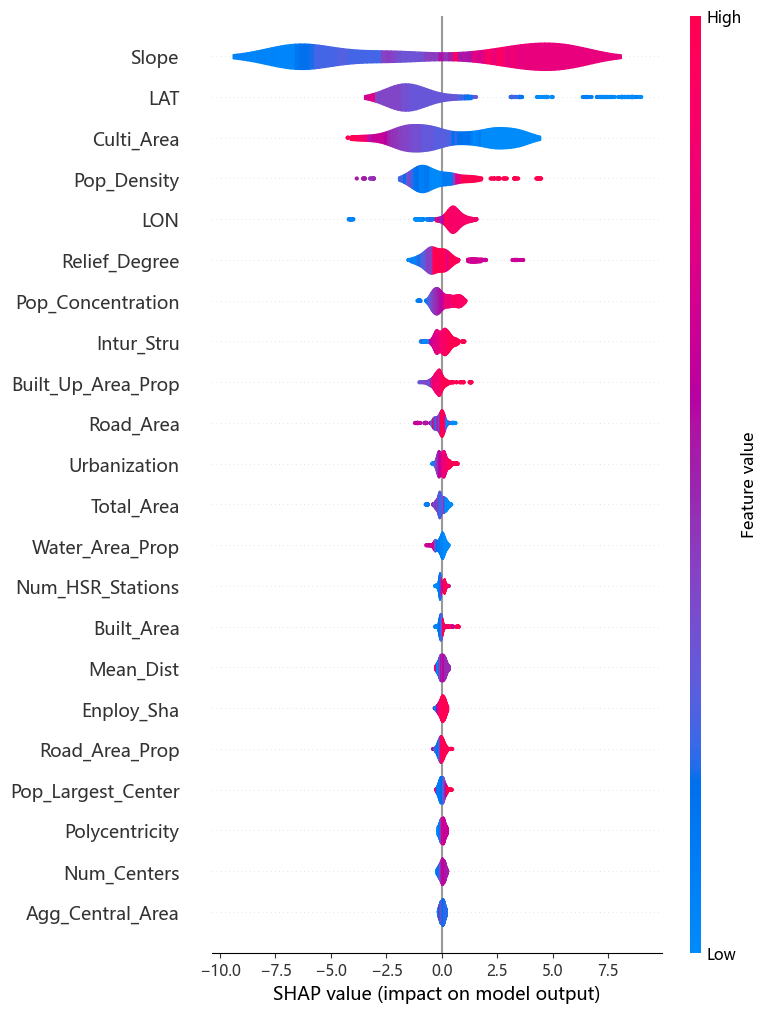

In [12]:
shap.summary_plot(shap_values, test_data_df, plot_type="violin", max_display=len(test_data_df.columns))

In [ ]:

shap_abs_mean = np.abs(shap_values).mean(axis=0)


feature_importance = dict(zip(test_data_df.columns, shap_abs_mean))


sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

sorted_feature_names = [feature[0] for feature in sorted_features]

print(sorted_feature_names)


['Slope', 'LAT', 'Culti_Area', 'Pop_Density', 'LON', 'Relief_Degree', 'Pop_Concentration', 'Intur_Stru', 'Built_Up_Area_Prop', 'Road_Area', 'Urbanization', 'Total_Area', 'Water_Area_Prop', 'Num_HSR_Stations', 'Built_Area', 'Mean_Dist', 'Enploy_Sha', 'Road_Area_Prop', 'Pop_Largest_Center', 'Polycentricity', 'Num_Centers', 'Agg_Central_Area']


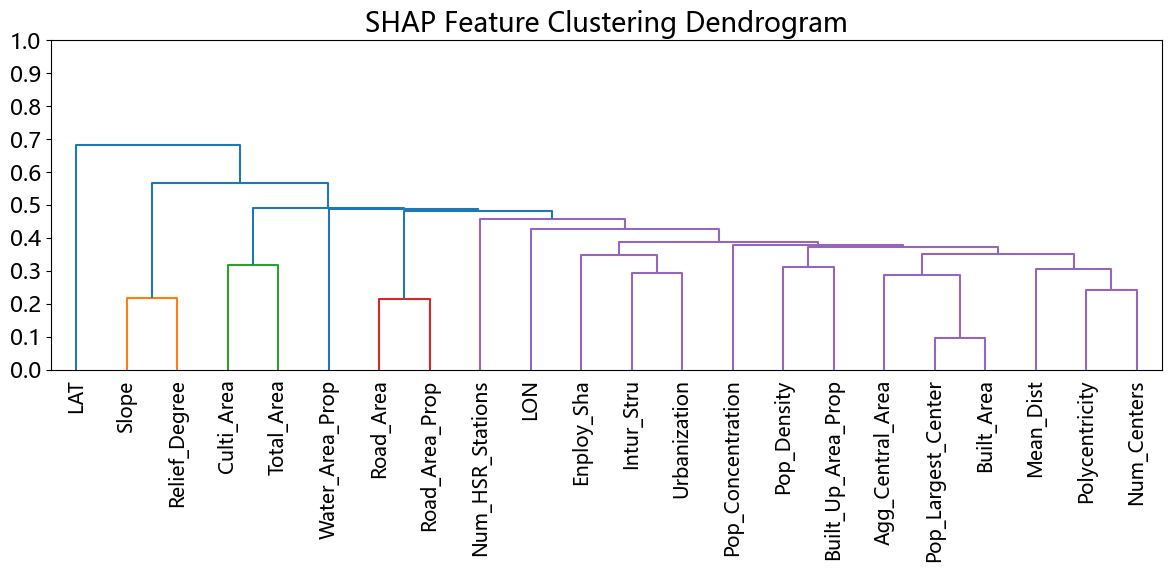

In [ ]:
import shap
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16


clustering = shap.utils.hclust(test_data_df)


plt.figure(figsize=(12, 6))

dendrogram(clustering, labels=test_data_df.columns.tolist(), leaf_font_size=14)


plt.title("SHAP Feature Clustering Dendrogram")

plt.yticks(np.arange(0, 1.1, 0.1))  


plt.xticks(rotation=90)


plt.tight_layout()

plt.show()


In [ ]:
selected_features=X_coords_sclaled.columns.tolist()
current_features=['Slope']

settings = {
    
    "metric": 'mse',  
    "estimator_list": 'auto',  
    "task": 'regression', 
    "eval_method": 'cv', 
    "n_splits": 5, 
    "verbose": -1
}

train_data_sub = X_train[current_features]
test_data_sub = X_test[current_features]

automl = AutoML()
automl.fit(train_data_sub,y_train,** settings)
y_pred = automl.predict(test_data_sub)
current_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
print(f"Initial RMSE: {current_rmse:.4f}")



Initial RMSE: 9.4967


In [20]:
candidate=[  'LAT', 'Culti_Area', 'Total_Area', 'Water_Area_Prop', 'Road_Area', 'Pop_Density', 'Built_Up_Area_Prop', 
 'LON', 'Pop_Concentration', 'Urbanization',  'Num_HSR_Stations', 'Enploy_Sha',  'Built_Area', 
 'Mean_Dist',  'Polycentricity']

In [ ]:
current_rmse=9.4967
current_features=['Slope']


for id,feature in enumerate(candidate):
    

    print(f"---{id}--- Current Feature:{feature}     Baisc Features:{current_features}")
    current_features.append(feature)

 
    train_data_sub = X_train[current_features]
    test_data_sub = X_test[current_features]

    automl = AutoML()
    automl.fit(train_data_sub,y_train,** settings)
    y_pred = automl.predict(test_data_sub)
    new_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)

    imp=100*(current_rmse-new_rmse)/34.2144     
    
    print(f"---{id}--- RMSE:  CurRMSE: {current_rmse:.4f}      NewRMSE: {new_rmse:.4f})   Imp:{imp:0.4f}   IsSave:{imp>=0}")
    print()


    if imp>=0:
        current_rmse = new_rmse

    else:
        current_features.pop()

---0--- Current Feature:LAT     Baisc Features:['Slope']
---0--- RMSE:  CurRMSE: 9.4967      NewRMSE: 8.3127)   Imp:3.4605   IsSave:True

---1--- Current Feature:Culti_Area     Baisc Features:['Slope', 'LAT']
---1--- RMSE:  CurRMSE: 8.3127      NewRMSE: 6.1155)   Imp:6.4219   IsSave:True

---2--- Current Feature:Total_Area     Baisc Features:['Slope', 'LAT', 'Culti_Area']
---2--- RMSE:  CurRMSE: 6.1155      NewRMSE: 4.9879)   Imp:3.2957   IsSave:True

---3--- Current Feature:Water_Area_Prop     Baisc Features:['Slope', 'LAT', 'Culti_Area', 'Total_Area']
---3--- RMSE:  CurRMSE: 4.9879      NewRMSE: 4.9917)   Imp:-0.0111   IsSave:False

---4--- Current Feature:Road_Area     Baisc Features:['Slope', 'LAT', 'Culti_Area', 'Total_Area']
---4--- RMSE:  CurRMSE: 4.9879      NewRMSE: 4.9388)   Imp:0.1435   IsSave:True

---5--- Current Feature:Pop_Density     Baisc Features:['Slope', 'LAT', 'Culti_Area', 'Total_Area', 'Road_Area']
---5--- RMSE:  CurRMSE: 4.9388      NewRMSE: 5.4979)   Imp:-1.634

In [ ]:
addRMSE_list = [5.01, 9.50] + [ 8.31, 6.12, 4.99, 4.99, 4.94, 5.50, 4.76, 4.77, 5.07, 4.76, 4.75,4.76,4.77,4.75, 4.97 ]
Imp_list = [None, None] +  [3.46, 6.42, 3.3, -0.01, 0.14, -1.6, 0.52, -0.03, -0.91,0.01, 0.03, -0.04, -0.06, 0.01, -0.64]



In [23]:
value=4.7485
100*( 34.2144-value)/34.2144

86.12134072203516

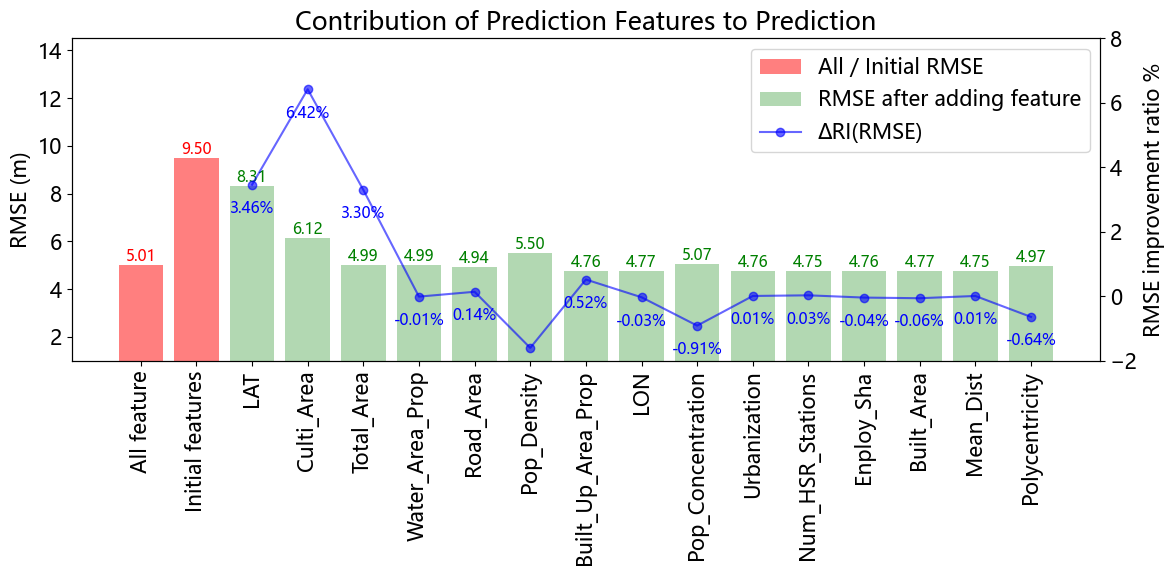

In [ ]:
import matplotlib.pyplot as plt


plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = 'Microsoft YaHei'



filtered_features=[  'LAT', 'Culti_Area', 'Total_Area', 'Water_Area_Prop', 'Road_Area', 'Pop_Density', 'Built_Up_Area_Prop', 
 'LON', 'Pop_Concentration', 'Urbanization',  'Num_HSR_Stations', 'Enploy_Sha',  'Built_Area', 
 'Mean_Dist',  'Polycentricity']

current_features = ["Slope"]

addRMSE_list = [5.01, 9.50] + [ 8.31, 6.12, 4.99, 4.99, 4.94, 5.50, 4.76, 4.77, 5.07, 4.76, 4.75,4.76,4.77,4.75, 4.97 ]
Imp_list = [None, None] +  [3.46, 6.42, 3.3, -0.01, 0.14, -1.6, 0.52, -0.03, -0.91,0.01, 0.03, -0.04, -0.06, 0.01, -0.64]





all_features = ["All feature", "Initial features"] + filtered_features
X = list(range(1, len(all_features) + 1 ))

plt.figure(figsize=(12, 6)) 


ax1 = plt.gca()

ax1.bar(X[0], addRMSE_list[0], color='red', alpha=0.5)

ax1.bar(X[1], addRMSE_list[1], color='red', alpha=0.5, label='All / Initial RMSE')

ax1.bar(X[2:], addRMSE_list[2:], color='green', alpha=0.3, label='RMSE after adding feature')
ax1.set_ylabel('RMSE (m)')
ax1.set_ylim(1, max(addRMSE_list) +5)


for i, v in zip(X, addRMSE_list):
    if i == 1:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='red')
    elif i == 2:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='red')
    else:
        ax1.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom',  fontsize=11, color='green')


ax2 = ax1.twinx()

ax2.plot(X[2:], Imp_list[2:], color='blue', marker='o', alpha=0.6, label='ΔRI(RMSE)')
ax2.set_ylabel('RMSE improvement ratio %')
ax2.set_ylim(-2, 8)


for i, v in zip(X[2:], Imp_list[2:]):

    ax2.annotate(f'{v:.2f}%', (i, v-1), ha='center', va='bottom', color='blue', fontsize=11)
   

ax1.set_xticks(X)
ax1.set_xticklabels(all_features, rotation=90)

plt.title('Contribution of Prediction Features to Prediction')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


In [ ]:
selected_features=X_coords_sclaled.columns.tolist()

current_features=['Slope', 'LAT', 'Culti_Area', 'Total_Area', 'Water_Area_Prop', 'Road_Area', 'Pop_Density', 'Built_Up_Area_Prop',  'LON'] 

settings = {
    
    "metric": 'mse',  
    "estimator_list": 'auto',  
    "task": 'regression', 
    "eval_method": 'cv', 
    "n_splits": 5, 
    "verbose": -1
}

train_data_sub = X_train[current_features]
test_data_sub = X_test[current_features]

automl = AutoML()
automl.fit(train_data_sub,y_train,** settings)
y_pred = automl.predict(test_data_sub)
current_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
print(f"SHAP-9 : {current_rmse:.4f}")



SHAP-9 : 4.7740


In [24]:
value=4.7740
100*( 34.2144-value)/34.2144

86.04681069958846

In [29]:
selected_features=X_coords_sclaled.columns.tolist()

current_features=['Slope', 'LAT', 'Culti_Area', 'Pop_Density' ,  'LON','Road_Area',  'Built_Up_Area_Prop', 'Total_Area','Pop_Concentration'] 

settings = {
    
    "metric": 'mse',  
    "estimator_list": 'auto',  
    "task": 'regression', 
    "eval_method": 'cv', 
    "n_splits": 5, 
    "verbose": -1
}
# 计算基准模型性能
train_data_sub = X_train[current_features]
test_data_sub = X_test[current_features]

automl = AutoML()
automl.fit(train_data_sub,y_train,** settings)
y_pred = automl.predict(test_data_sub)
current_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
print(f"ML-9 : {current_rmse:.4f}")


ML-9 : 5.1663


In [25]:
value=5.1663
100*( 34.2144-value)/34.2144

84.9002174523008

In [30]:
selected_features=X_coords_sclaled.columns.tolist()

current_features=['LON', 'LAT','Slope',"Road_Area",  'Culti_Area',  'Pop_Density',  'Total_Area', 'Water_Area_Prop',  'Built_Up_Area_Prop'] 

settings = {
    
    "metric": 'mse',  
    "estimator_list": 'auto',  
    "task": 'regression', 
    "eval_method": 'cv', 
    "n_splits": 5, 
    "verbose": -1
}
# 计算基准模型性能
train_data_sub = X_train[current_features]
test_data_sub = X_test[current_features]

automl = AutoML()
automl.fit(train_data_sub,y_train,** settings)
y_pred = automl.predict(test_data_sub)
current_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
print(f"MI-9 : {current_rmse:.4f}")

MI-9 : 4.7666


In [26]:
value=4.7666
100*( 34.2144-value)/34.2144

86.0684390198279

In [39]:
selected_features=X_coords_sclaled.columns.tolist()

current_features=['Slope', 'Culti_Area', 'LAT',  'Pop_Density', 'LON', 'Water_Area_Prop',   'Built_Up_Area_Prop',  'Road_Area_Prop',   'Num_HSR_Stations' ] 

settings = {
    
    "metric": 'mse',  
    "estimator_list": 'auto',  
    "task": 'regression', 
    "eval_method": 'cv', 
    "n_splits": 5, 
    "verbose": -1
}
# 计算基准模型性能
train_data_sub = X_train[current_features]
test_data_sub = X_test[current_features]

automl = AutoML()
automl.fit(train_data_sub,y_train,** settings)
y_pred = automl.predict(test_data_sub)
current_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)),4)
print(f"CPML-9 : {current_rmse:.4f}")

CPML-9 : 4.7641


In [27]:
value=4.7641
100*( 34.2144-value)/34.2144

86.07574588477367

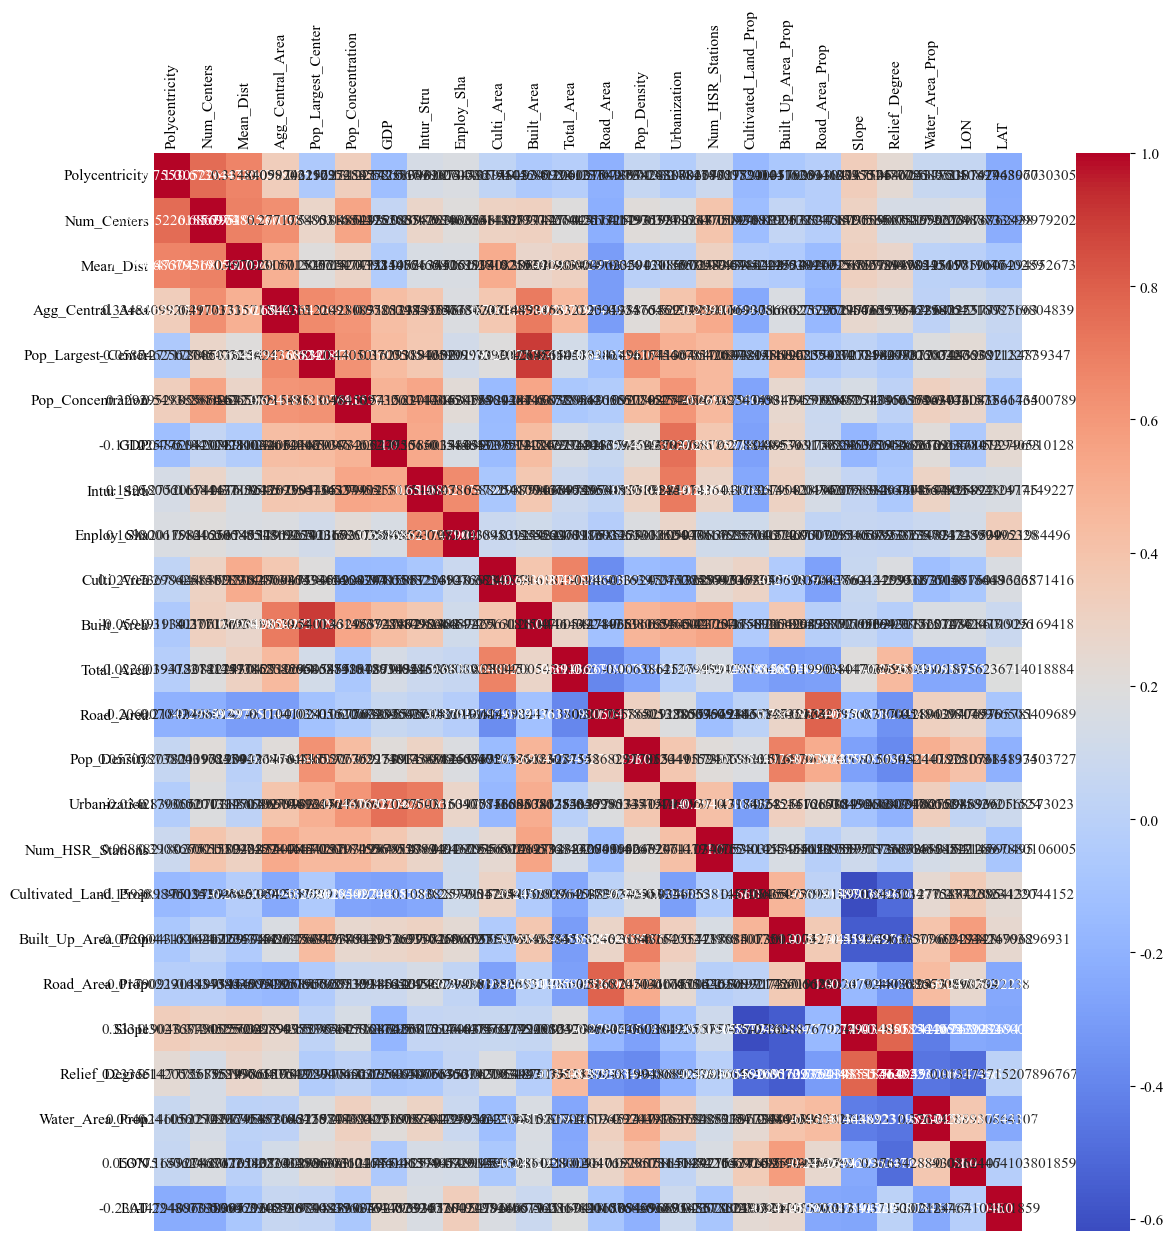

In [ ]:
import seaborn as sns
import warnings
import pickle

# 计算相关系数矩阵
correlation_matrix = test_data_df.corr()

plt.figure(figsize=(14, 14))
# 设置字体样式为Times New Roman，解决中文显示问题
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11  # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


# 绘制热图
ax = sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt="", 
    # annot_kws={"size": 10}, 
    # cbar_kws={"shrink": 0.8}
)


# 调整标题在顶部
ax.xaxis.tick_top()
ax.tick_params(axis='both', which='both', length=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center') 
ax.xaxis.set_label_position('top')

# plt.show()


In [21]:
# 设置阈值
from collections import defaultdict
correlation_matrix = correlation_matrix.abs() 
threshold = 0.7

# 构建图：将相关性>=0.7的变量连通
graph = defaultdict(set)
for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        if i != j and correlation_matrix.loc[i, j] >= threshold:
            graph[i].add(j)
            graph[j].add(i)

# 找到所有连通子图（合并变量组）
visited = set()
groups = []

def dfs(node, group):
    for neighbor in graph[node]:
        if neighbor not in visited:
            visited.add(neighbor)
            group.append(neighbor)
            dfs(neighbor, group)

for node in correlation_matrix.columns:
    if node not in visited:
        group = [node]
        visited.add(node)
        dfs(node, group)
        groups.append(sorted(group))

# 将未与任何变量相关的变量（孤立点）添加为单独组
all_grouped_vars = set([v for group in groups for v in group])
all_vars = set(correlation_matrix.columns)
for var in all_vars - all_grouped_vars:
    groups.append([var])

# 输出所有组
print("变量分组结果：")
for idx, g in enumerate(groups, 1):
    print(f"Group {idx}: {g}")

变量分组结果：
Group 1: ['Num_Centers', 'Polycentricity']
Group 2: ['Mean_Dist']
Group 3: ['Agg_Central_Area', 'Built_Area', 'Pop_Largest_Center']
Group 4: ['Pop_Concentration']
Group 5: ['GDP', 'Intur_Stru', 'Urbanization']
Group 6: ['Enploy_Sha']
Group 7: ['Culti_Area']
Group 8: ['Total_Area']
Group 9: ['Road_Area', 'Road_Area_Prop']
Group 10: ['Pop_Density']
Group 11: ['Num_HSR_Stations']
Group 12: ['Cultivated_Land_Prop']
Group 13: ['Built_Up_Area_Prop']
Group 14: ['Relief_Degree', 'Slope']
Group 15: ['Water_Area_Prop']
Group 16: ['LON']
Group 17: ['LAT']


## Other models

### ML

In [17]:
# current_features=['Slope', 'LAT', 'Culti_Area', 'Pop_Density' ,  'LON','Road_Area',  'Built_Up_Area_Prop', 'Total_Area','Pop_Concentration'] 
selected_features=X_coords_sclaled.columns.tolist()
y_pred = automl.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Validation RMSE: {rmse:.4f}") # Validation RMSE: 4.1006

importance = automl.model.feature_importances_
feature_names = selected_features   # 如果你用的是特征名列表
sorted_idx = np.argsort(importance)[::-1]
print("=== Feature Importance Ranking ===")
for idx in sorted_idx:
    print(f"{feature_names[idx]:25s}  {importance[idx]:.6f}")

Validation RMSE: 5.0089
=== Feature Importance Ranking ===
Slope                      0.312204
LAT                        0.168168
Culti_Area                 0.109032
Pop_Density                0.086788
Relief_Degree              0.059169
LON                        0.057157
Road_Area                  0.030847
Total_Area                 0.027811
Built_Up_Area_Prop         0.025532
Pop_Concentration          0.022538
Water_Area_Prop            0.020614
Intur_Stru                 0.015710
Road_Area_Prop             0.011170
Urbanization               0.010643
Built_Area                 0.008874
Pop_Largest_Center         0.008787
Mean_Dist                  0.005961
Enploy_Sha                 0.004043
Num_HSR_Stations           0.003896
Num_Centers                0.003874
Agg_Central_Area           0.003618
Polycentricity             0.003563


### MI

In [ ]:
current_features=['LON', 'LAT','Slope',"Road_Area",  'Culti_Area',  'Pop_Density',  'Total_Area', 'Water_Area_Prop',  'Built_Up_Area_Prop'] 


In [18]:
mi_scores = mutual_info_regression(X_test, y_test, random_state=42)

# 2. 整理：特征名 + MI
mi_df = pd.DataFrame({
    'Feature': selected_features,
    'MI': mi_scores
})

# 3. 按 MI 降序排序
mi_df_sorted = mi_df.sort_values(by='MI', ascending=False)
mi_df_sorted

,Feature,MI
20,LON,1.634923
21,LAT,1.552226
17,Slope,1.478700
11,Road_Area,1.446384
8,Culti_Area,1.440827
18,Relief_Degree,1.331683
12,Pop_Density,1.274615
10,Total_Area,1.170116
19,Water_Area_Prop,1.088355
15,Built_Up_Area_Prop,0.933483


### ML PM

In [32]:
from flaml import AutoML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# automl.estimator_list
# for model in ['lgbm', 'rf', 'xgboost', 'extra_tree', 'catboost']:
    
settings = {
    # "time_budget": 1*60,  # total running time in seconds s
    "metric": 'mse',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape'] #
    # "estimator_list": 'auto',  # list of ML learners; 'auto' means try all 
    "estimator_list": 'auto',  # list of ML learners; 'auto' means try all  
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5, #5-fold cross validation
    "verbose": -1
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)
y_pred=automl.predict(X_test)



In [19]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer, mean_squared_error
"""
n_repeats 的作用就是：🔹 重复打乱同一个特征多次，然后取平均和标准差，避免单次打乱带来的偶然性。

"""

# 定义 RMSE scorer（越大越好 → 这里要加上 greater_is_better=False）
rmse_scorer = make_scorer(
    lambda y_true, y_pred: mean_squared_error(y_true, y_pred),
    greater_is_better=False
)

def ann_perm_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    r = permutation_importance(
        model, X, y,
        scoring=rmse_scorer,  # 使用 RMSE
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )
    imp = pd.DataFrame({
        "feature": feature_names,
        "perm_mean": r.importances_mean,  # RMSE 恶化量，越大越重要
        "perm_std":  r.importances_std
    })
    imp["rank"] = imp["perm_mean"].rank(ascending=False, method="dense").astype(int)
    imp=imp.sort_values(by="rank", ascending=True).reset_index(drop=True)
    return imp



perm = ann_perm_importance(automl.model, X_test, y_test, feature_names=X_coords_sclaled.columns.tolist(),n_repeats=1)
perm


,feature,perm_mean,perm_std,rank
0,Slope,63.442624,0.0,1
1,Culti_Area,21.120968,0.0,2
2,LAT,18.118601,0.0,3
3,Pop_Density,5.831422,0.0,4
4,Relief_Degree,4.536317,0.0,5
5,LON,2.038944,0.0,6
6,Water_Area_Prop,0.733602,0.0,7
7,Road_Area_Prop,0.490270,0.0,8
8,Built_Up_Area_Prop,0.378917,0.0,9
9,Road_Area,0.084538,0.0,10


In [ ]:
current_features=['Slope', 'Culti_Area', 'LAT',  'Pop_Density', 'LON', 'Water_Area_Prop',   'Built_Up_Area_Prop',  'Road_Area_Prop',   'Num_HSR_Stations' ] 
